### Theory

Logistic Regression is the workhorse of Machine Learning.

It classifies data by passing a linear output (wx+b) through a sigmoid activation function.

It learns the w and b which minimises the Binary Cross-Entropy loss. Adding an L2 regularisation ensures that gradients do not explode.

bce = -(y.log(y_pred) + (1-y).log(1-y_pred))

l2_loss = lambda*(weights**2)

### Implementation

In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [41]:
class LogisticRegression:
    
    def __init__(self, learning_rate = 0.01, epochs = 1000, batch_size = 32, l2_lambda = 0.01):        
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.l2_lambda = l2_lambda
        self.weights = None
        self.bias = None
        self.loss_history = []

    def sigmoid(self, z):       
        return np.where( z>=0, 1/(1+np.exp(-z)), np.exp(z)/(1+np.exp(z)) )

    def _initialise_weights(self, n_features):        
        self.weights = np.random.randn(n_features) * 0.01
        self.bias = 0.01

    def _compute_loss(self, y, y_pred, n_samples):
        eps = 1e-15
        y_pred = np.clip(y_pred, eps, 1-eps)
        # Binary Cross-Entropy Loss
        bce_sample =  - (y*np.log(y_pred) + (1-y)*np.log(1-y_pred))
        bce_loss = np.sum(bce_sample)/ n_samples
        # L2 Regularisation
        l2_loss = (self.l2_lambda/2)*np.sum(self.weights**2)
        return bce_loss + l2_loss
        
    def fit(self, X, y):        
        n_samples, n_features = X.shape
        self._initialise_weights(n_features)

        for epoch in range(self.epochs):             
            np.random.seed(42)
            shuffled_ids = np.random.permutation(n_samples)
            X_ = X[shuffled_ids]
            y_ = y[shuffled_ids]
            
            for i in range(0, n_samples, self.batch_size):
                X_batch = X_[i:i+self.batch_size]
                y_batch = y_[i:i+self.batch_size]
                m = len(X_batch) # actual batch size (last batch might be smaller)
                
                # forward pass
                y_batch_pred = self.sigmoid(X_batch @ self.weights + self.bias)    #  linear output passed through sigmoid activation
                
                # error_signal
                error = y_batch_pred - y_batch
                
                # backward pass
                
                ## compute gradients
                dw = (1/m) * (X_batch.T @ error) + (self.l2_lambda * self.weights)
                db = (1/m) *np.sum(error)

                ## update parameters
                self.weights -= self.learning_rate * dw
                self.bias -= self.learning_rate * db

            
            # At the end of each epoch, compute loss on whole dataset
            y_pred = self.sigmoid(X @ self.weights + self.bias)  
            epoch_loss = self._compute_loss(y, y_pred, n_samples)
            self.loss_history.append(epoch_loss)

            # Optional: Print progress
            if epoch % 100 == 0:
                print(f"Epoch {epoch} Loss = {epoch_loss:.4f}")

        return self


    def predict_prob(self, X):
        return self.sigmoid( X @ self.weights + self.bias)

    def predict(self, X, threshold = 0.5):
        probs  = self.predict_prob(X)
        return (probs >= threshold).astype(int)

        

In [42]:
# generate dummy data

# Set seed for reproducibility
np.random.seed(42)

def generate_sample_data(n_samples=1000, n_features=2):
    """
    Generates a binary classification dataset with:
    - 2 informative features (linearly separable with some noise)
    - Class 0 centered at (-2, -2)
    - Class 1 centered at (+2, +2)
    - Small Gaussian noise added
    """
    # Generate class 0 (50%)
    X0 = np.random.randn(int(n_samples/2), n_features) * 1.5 + np.array([-2, -2])
    y0 = np.zeros(int(n_samples/2))
    
    # Generate class 1 (50%)
    X1 = np.random.randn(int(n_samples/2), n_features) * 1.5 + np.array([2, 2])
    y1 = np.ones(int(n_samples/2))
    
    # Combine and shuffle
    X = np.vstack([X0, X1])
    y = np.hstack([y0, y1])
    
    # Shuffle the data (important to avoid order bias)
    shuffle_idx = np.random.permutation(n_samples)
    X = X[shuffle_idx]
    y = y[shuffle_idx]
    
    return X, y

# Generate 1000 samples with 2 features
X, y = generate_sample_data(n_samples=1000, n_features=2)

print(f"X shape: {X.shape}")  # (1000, 2)
print(f"y shape: {y.shape}")  # (1000,)
print(f"Class balance: {np.mean(y):.2f} (should be ~0.5)")
print(f"First 5 samples:\n{X[:5]}")
print(f"First 5 labels: {y[:5].astype(int)}")

X shape: (1000, 2)
y shape: (1000,)
Class balance: 0.50 (should be ~0.5)
First 5 samples:
[[ 3.53609379  2.88879042]
 [ 4.49188882  1.31435562]
 [-4.41122485 -1.72304921]
 [ 3.61401071  2.03196747]
 [-3.13452612 -4.13338056]]
First 5 labels: [1 1 0 1 0]


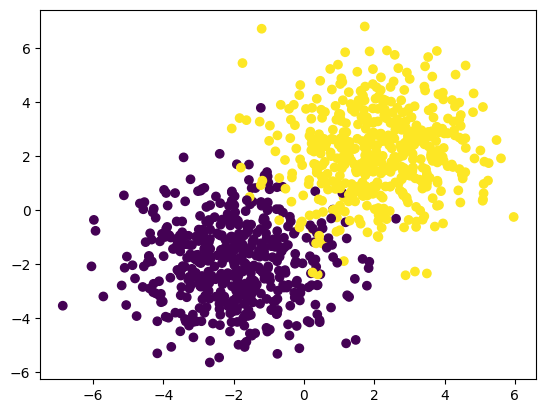

In [43]:
plt.scatter(x = X[:,0], y = X[:,1], c = y)

In [44]:
np.random.seed(42)
train_ids = np.random.rand(X.shape[0]) <= .8
test_ids = ~ train_ids

X_train, y_train, X_test, y_test = X[train_ids], y[train_ids], X[test_ids], y[test_ids]

In [53]:
clf = LogisticRegression()
clf.fit(X_train, y_train)

Epoch 0 Loss = 0.3876
Epoch 100 Loss = 0.0982
Epoch 200 Loss = 0.0977
Epoch 300 Loss = 0.0976
Epoch 400 Loss = 0.0976
Epoch 500 Loss = 0.0976
Epoch 600 Loss = 0.0976
Epoch 700 Loss = 0.0976
Epoch 800 Loss = 0.0976
Epoch 900 Loss = 0.0976


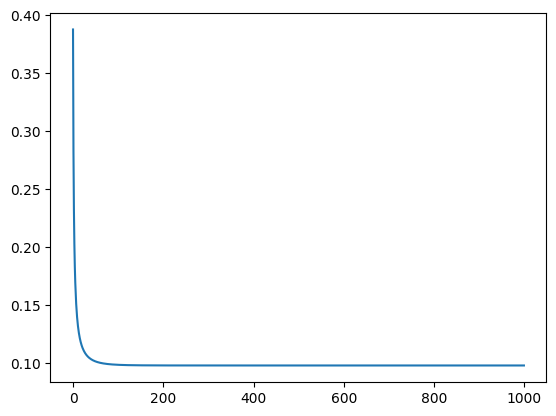

In [55]:
plt.plot(clf.loss_history)

In [46]:
y_test_pred = clf.predict(X_test)

In [47]:
def accuracy(y, y_pred):
    return np.mean(y == y_pred)

In [48]:
accuracy(y_test, y_test_pred)

np.float64(0.9849246231155779)

In [56]:
# sklearn validation

from sklearn.linear_model import LogisticRegression as LogisticRegression2

In [50]:
clf2 = LogisticRegression2()
clf2.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [51]:
y_test_pred2 = clf2.predict(X_test)

accuracy(y_test, y_test_pred2)

np.float64(0.9849246231155779)

### Notes

Why does logistic regression without the l2 regularisation fail to converge if the data clsasses are linearly separable?